In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Change this if your file has another name
RESULTS_FILE = Path("results/results_copy.csv")

df = pd.read_csv(RESULTS_FILE)

# Keep only complete benchmark rows
df = df[df["file_type"].isin(["csv", "parquet"])].copy()

# Make numeric columns safe
num_cols = [
    "objects", "size_mb",
    "upload_seconds", "upload_mbps",
    "download_seconds", "download_mbps",
    "list_seconds",
    "query_seconds", "query_rows", "query_result_groups"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Order sizes correctly
df["size"] = pd.Categorical(df["size"], categories=["S", "M", "L"], ordered=True)
df = df.sort_values(["storage", "size", "file_type"])

df.head()

,bench_ts,storage,size,file_type,operation,objects,size_mb,generate_seconds,generate_mbps,upload_seconds,...,download_seconds,download_mbps,list_seconds,query_filter_region,query_start_ts,query_end_ts,query_grouped_by,query_seconds,query_rows,query_result_groups
4,2026-05-10T16:54:02.900323+00:00,aws,S,csv,generate+upload+download+list+query,1,298.82,0.0,1.253360e+09,188.331,...,126.090,2.37,0.584,Eurozone,2026-04-10,2026-04-20,event_type,288.697,584041,4
5,2026-05-10T17:04:09.653951+00:00,aws,S,parquet,generate+upload+download+list+query,1,78.92,0.0,1.655076e+08,26.355,...,27.580,2.86,0.409,Eurozone,2026-04-10,2026-04-20,event_type,46.045,584041,4
10,2026-05-10T18:12:06.694369+00:00,aws,M,csv,generate+upload+download+list+query,5,1494.12,0.0,0.000000e+00,656.004,...,496.635,3.01,0.377,Eurozone,2026-04-10,2026-04-20,event_type,811.353,2916266,4
11,2026-05-10T18:44:53.080042+00:00,aws,M,parquet,generate+upload+download+list+query,5,394.61,0.0,5.517071e+08,242.405,...,298.092,1.32,0.432,Eurozone,2026-04-10,2026-04-20,event_type,177.007,2916266,4
16,2026-05-10T21:30:30.546540+00:00,aws,L,csv,generate+upload+download+list+query,20,5976.46,0.0,0.000000e+00,2624.007,...,1986.533,3.01,0.450,Eurozone,2026-04-10,2026-04-20,event_type,1926.243,11666670,4


In [11]:
summary = df[[
    "storage", "size", "file_type", "objects", "size_mb",
    "upload_seconds", "upload_mbps",
    "download_seconds", "download_mbps",
    "list_seconds", "query_seconds", "query_rows"
]]

summary

,storage,size,file_type,objects,size_mb,upload_seconds,upload_mbps,download_seconds,download_mbps,list_seconds,query_seconds,query_rows
4,aws,S,csv,1,298.82,188.331,1.59,126.090,2.37,0.584,288.697,584041
5,aws,S,parquet,1,78.92,26.355,2.99,27.580,2.86,0.409,46.045,584041
10,aws,M,csv,5,1494.12,656.004,2.28,496.635,3.01,0.377,811.353,2916266
11,aws,M,parquet,5,394.61,242.405,1.63,298.092,1.32,0.432,177.007,2916266
16,aws,L,csv,20,5976.46,2624.007,2.28,1986.533,3.01,0.450,1926.243,11666670
17,aws,L,parquet,20,1578.44,969.620,1.63,1192.368,1.32,0.500,583.555,11666670
2,azure,S,csv,1,298.82,318.501,0.94,162.346,1.84,0.066,254.588,584041
3,azure,S,parquet,1,78.92,61.245,1.29,61.363,1.29,0.062,15.678,584041
8,azure,M,csv,5,1494.12,1026.310,1.46,1229.971,1.21,0.071,758.786,2916266
9,azure,M,parquet,5,394.61,291.346,1.35,307.635,1.28,0.086,59.742,2916266


In [19]:
def plot_metric(metric, title, ylabel):
    storages = df["storage"].unique()
    
    fig, axes = plt.subplots(
        1, len(storages),
        figsize=(6 * len(storages), 4),
        sharey=False   # independent y-axis for each endpoint
    )

    if len(storages) == 1:
        axes = [axes]

    for ax, storage in zip(axes, storages):
        data = df[df["storage"] == storage]
        pivot = data.pivot(index="size", columns="file_type", values=metric)

        pivot.plot(kind="bar", ax=ax)

        ax.set_title(storage)
        ax.set_xlabel("Dataset size")
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="x", rotation=0)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

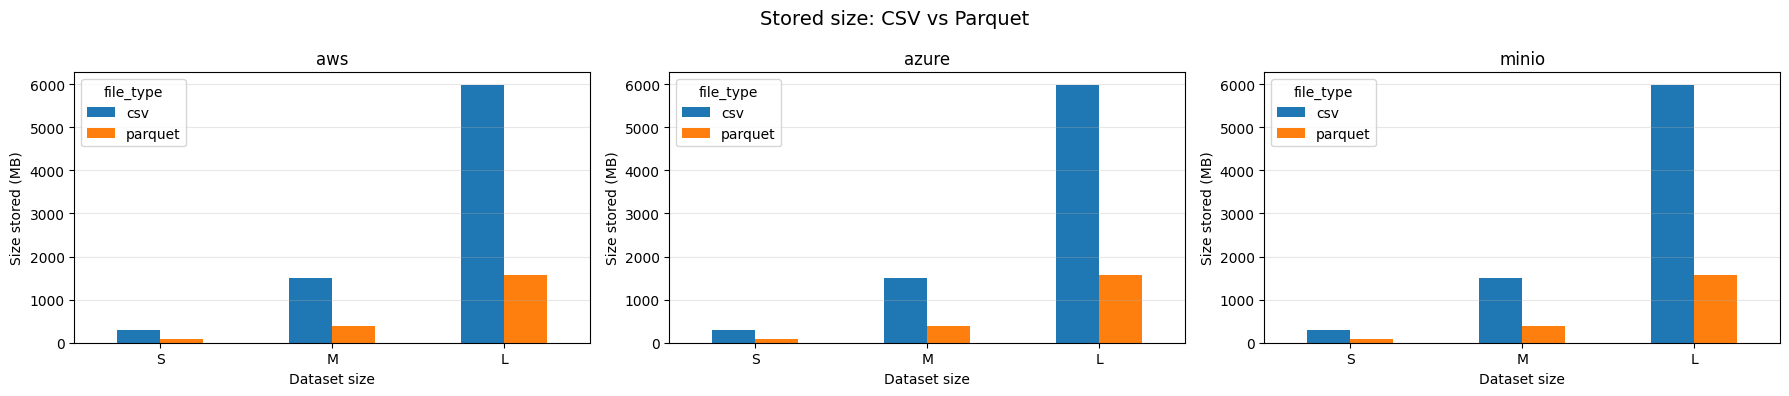

In [20]:
plot_metric(
    metric="size_mb",
    title="Stored size: CSV vs Parquet",
    ylabel="Size stored (MB)"
)

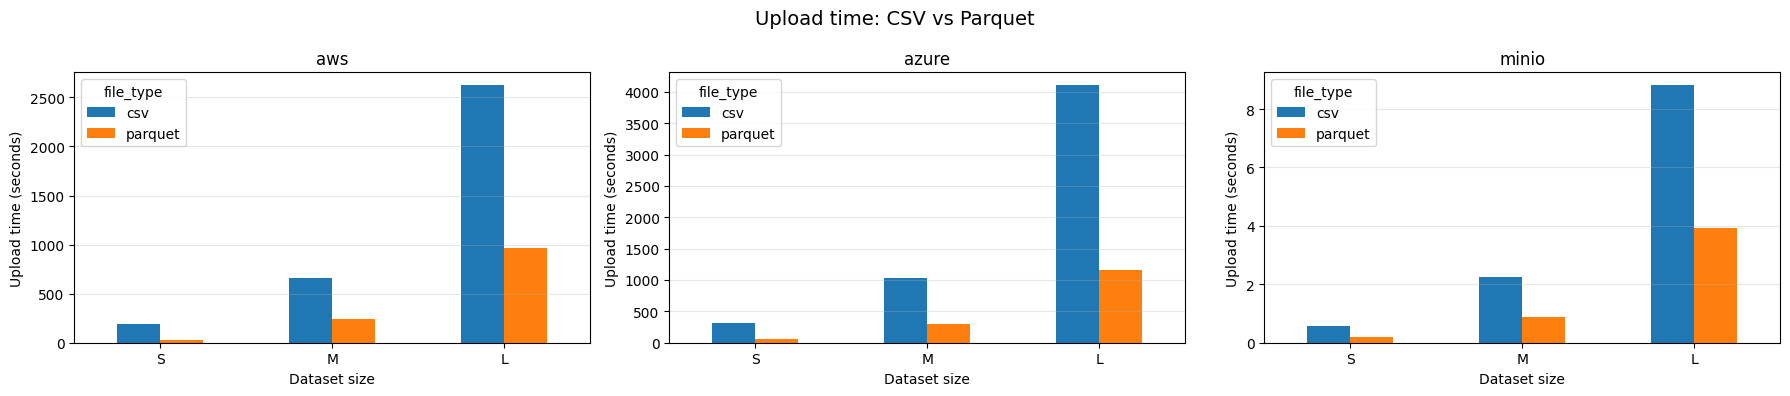

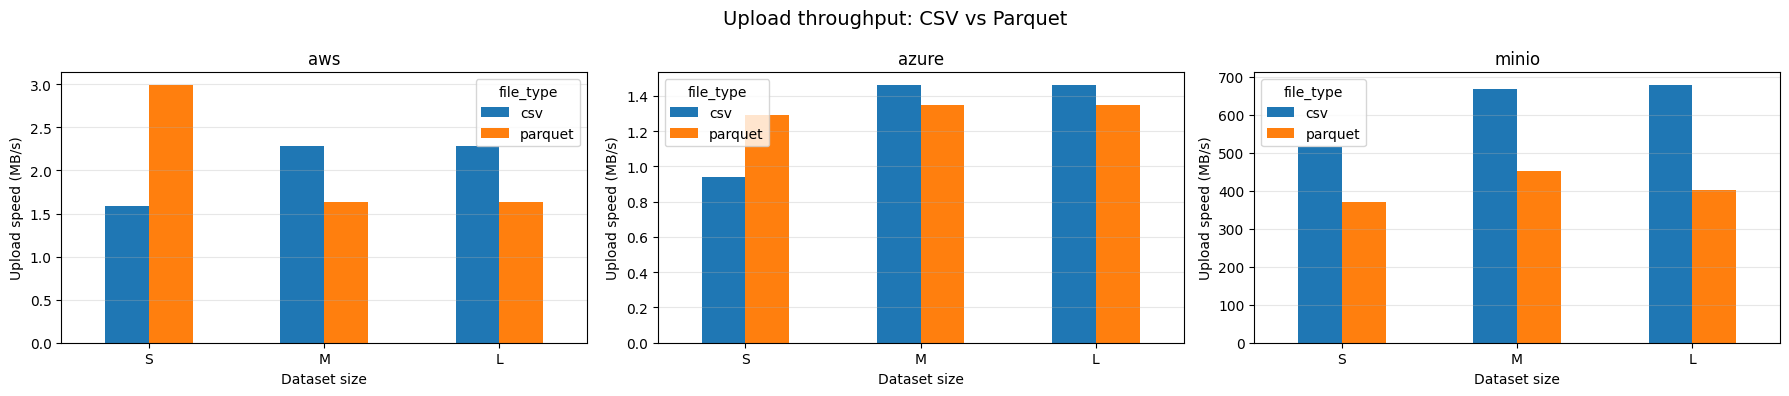

In [21]:
plot_metric(
    metric="upload_seconds",
    title="Upload time: CSV vs Parquet",
    ylabel="Upload time (seconds)"
)

plot_metric(
    metric="upload_mbps",
    title="Upload throughput: CSV vs Parquet",
    ylabel="Upload speed (MB/s)"
)

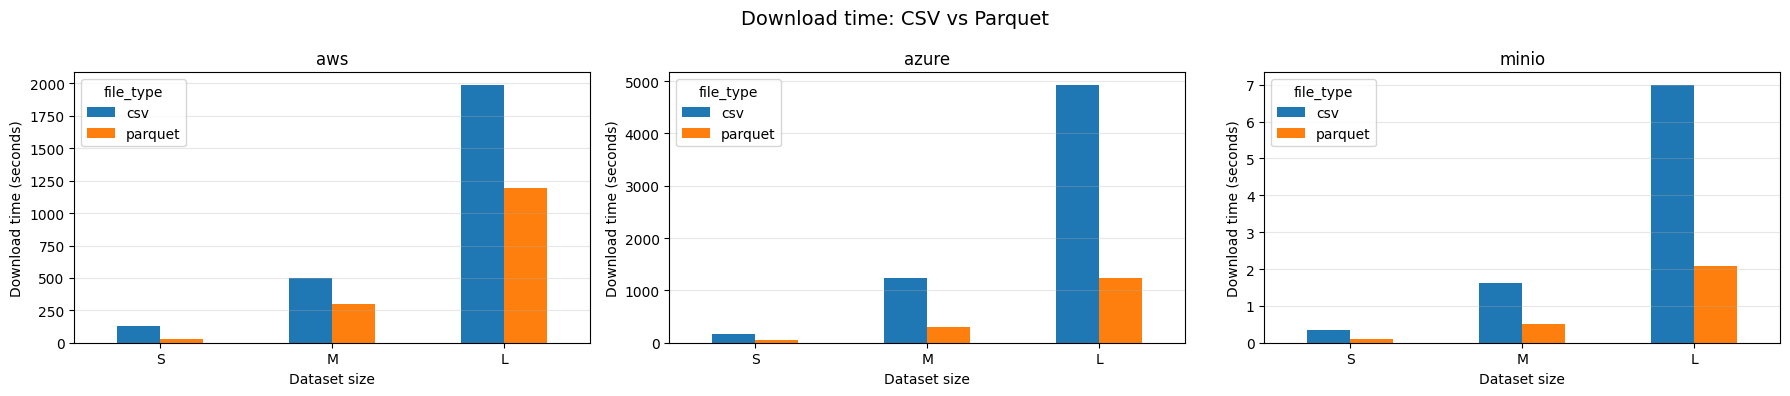

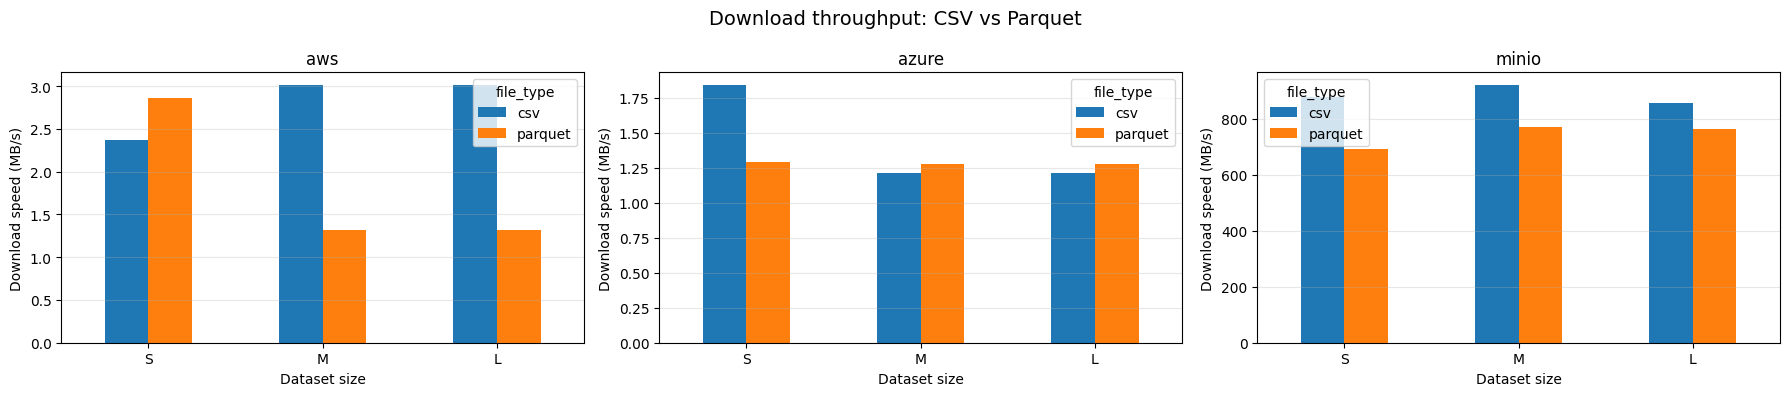

In [22]:
plot_metric(
    metric="download_seconds",
    title="Download time: CSV vs Parquet",
    ylabel="Download time (seconds)"
)

plot_metric(
    metric="download_mbps",
    title="Download throughput: CSV vs Parquet",
    ylabel="Download speed (MB/s)"
)

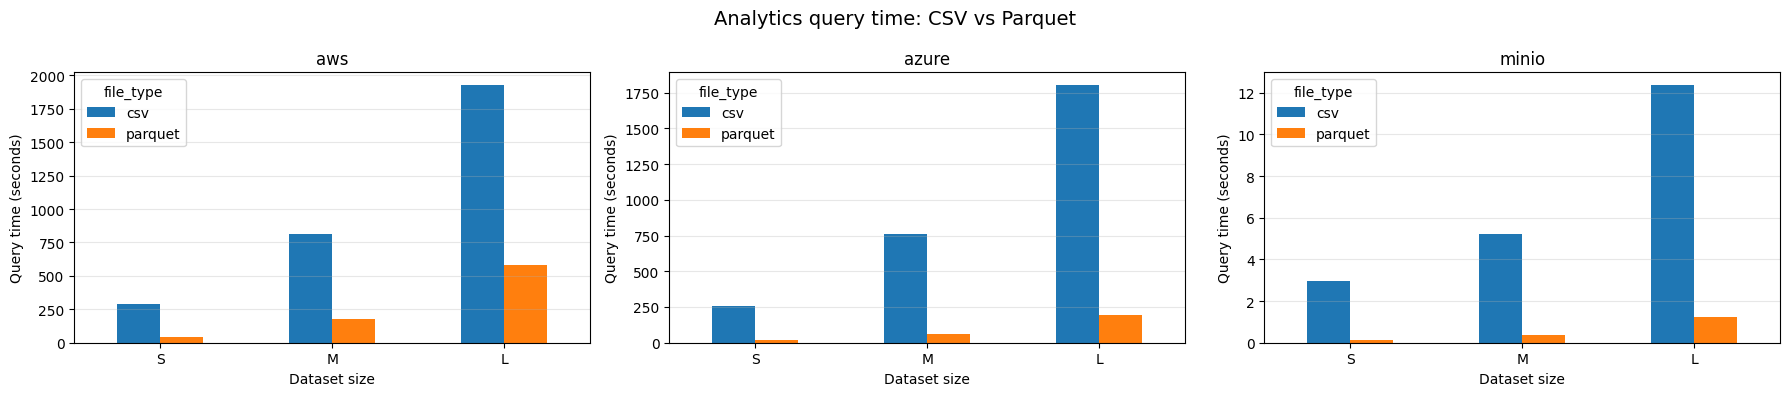

In [23]:
plot_metric(
    metric="query_seconds",
    title="Analytics query time: CSV vs Parquet",
    ylabel="Query time (seconds)"
)

In [24]:
pairs = df.pivot_table(
    index=["storage", "size"],
    columns="file_type",
    values=[
        "size_mb",
        "upload_seconds",
        "download_seconds",
        "query_seconds"
    ],
    aggfunc="mean"
)

improvement = pd.DataFrame(index=pairs.index)

improvement["parquet_size_reduction_%"] = (
    (1 - pairs[("size_mb", "parquet")] / pairs[("size_mb", "csv")]) * 100
)

improvement["upload_time_reduction_%"] = (
    (1 - pairs[("upload_seconds", "parquet")] / pairs[("upload_seconds", "csv")]) * 100
)

improvement["download_time_reduction_%"] = (
    (1 - pairs[("download_seconds", "parquet")] / pairs[("download_seconds", "csv")]) * 100
)

improvement["query_time_reduction_%"] = (
    (1 - pairs[("query_seconds", "parquet")] / pairs[("query_seconds", "csv")]) * 100
)

improvement = improvement.round(2)
improvement

parquet_size_reduction_%  upload_time_reduction_%  \
storage size                                                      
aws     S                        73.59                    86.01   
        M                        73.59                    63.05   
        L                        73.59                    63.05   
azure   S                        73.59                    80.77   
        M                        73.59                    71.61   
        L                        73.59                    71.61   
minio   S                        73.59                    63.45   
        M                        73.59                    60.91   
        L                        73.59                    55.61   

              download_time_reduction_%  query_time_reduction_%  
storage size                                                     
aws     S                         78.13                   84.05  
        M                         39.98                   78.18  
        L                         39.98                   69.71  
azure   S                         62.20                   93.84  
        M                         74.99                   92.13  
        L                         74.99                   89.07  
minio   S                         66.57                   94.95  
        M                         68.55                   92.82  
        L                         70.33                   90.03